In [1]:
# !!!I have added some lines to this existing cell to prepare somthing for model_4;
# data loading and preprocessing
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"


all_cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()


meta_cols = ["sequence_id", "sequence_counter", "gesture"]
tof_cols = [c for c in all_cols if c.startswith("tof_")]

use_cols = meta_cols + tof_cols

print("Using columns:", len(use_cols))


train_df = pd.read_csv(
    DATA_PATH,
    usecols=use_cols,
    low_memory=True
)

print("Data shape:", train_df.shape)

Using columns: 323
Data shape: (574945, 323)


In [2]:
# !!!I have added some lines to this existing cell to prepare somthing for model_4;


import json

LABEL2ID_PATH = PROJECT_ROOT / "results" / "preds" / "label2id.json"
assert LABEL2ID_PATH.exists(), f"Missing: {LABEL2ID_PATH}"

with open(LABEL2ID_PATH, "r", encoding="utf-8") as f:
    label2id = json.load(f)


num_classes = len(label2id)


id2label = [None] * num_classes
for lab, idx in label2id.items():
    id2label[idx] = lab

assert all(x is not None for x in id2label), "id2label has holes, check label2id.json"
print("Loaded label2id:", num_classes, "classes")
print("First 5 id2label:", id2label[:5])

Loaded label2id: 18 classes
First 5 id2label: ['Above ear - pull hair', 'Cheek - pinch skin', 'Drink from bottle/cup', 'Eyebrow - pull hair', 'Eyelash - pull hair']


In [3]:
# module 2: select TOF Columns
tof_df = train_df.sort_values(
    ["sequence_id", "sequence_counter"]
).reset_index(drop=True)

print("TOF-only DF shape:", tof_df.shape)

TOF-only DF shape: (574945, 323)


In [4]:
#!!!I have added some lines to this existing cell to prepare somthing for model_4;


# =========================
# Module 3: Convert rows to sequence-level samples
# Each sample = one sequence_id, variable length T, features = 320 TOF values
# =========================
X_seq, y_seq, seq_ids = [], [], []

for seq_id, g in tof_df.groupby("sequence_id"):
    X_seq.append(g[tof_cols].to_numpy())
    y_seq.append(g["gesture"].iloc[0])
    seq_ids.append(seq_id)                 #!!! sequence_id

print("Num sequences:", len(X_seq))
print("Example seq shape:", X_seq[0].shape)
print("Example seq_id:", seq_ids[0])

Num sequences: 8151
Example seq shape: (57, 320)
Example seq_id: SEQ_000007


In [5]:
# !!!I have added some lines to this existing cell to prepare somthing for model_4;

# =========================
# Module 4: Sequence length stats & filtering
# Keep ALL global-test seq_ids (1518) even if shorter than threshold
# =========================
import numpy as np
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
PRED_DIR = PROJECT_ROOT / "results" / "preds"
if 'numpy._core' not in sys.modules:
    sys.modules['numpy._core'] = sys.modules['numpy.core']
if 'numpy._core.multiarray' not in sys.modules:
    sys.modules['numpy._core.multiarray'] = sys.modules['numpy.core.multiarray']

# read global test split（1518）
global_test_seq = np.load(PRED_DIR / "split_test_seq_ids.npy", allow_pickle=True)
global_test_set = set(map(str, global_test_seq))

lengths = np.array([x.shape[0] for x in X_seq])
min_len = lengths.mean() - lengths.std()

X_filt, y_filt, seq_filt = [], [], []

for x, y, sid in zip(X_seq, y_seq, seq_ids):
    sid_str = str(sid)

    if (sid_str in global_test_set) or (x.shape[0] >= min_len):
        X_filt.append(x)
        y_filt.append(y)
        seq_filt.append(sid_str)

print("After filtering (global-test preserved):")
print("  X_filt:", len(X_filt))
print("  y_filt:", len(y_filt))
print("  seq_filt:", len(seq_filt))
print("  min_len threshold:", float(min_len))

assert len(X_filt) == len(y_filt) == len(seq_filt)

After filtering (global-test preserved):
  X_filt: 8145
  y_filt: 8145
  seq_filt: 8145
  min_len threshold: 35.14903603799025


In [6]:
# =========================
# Module 5: Reshape TOF features
# 320 = 5 sensors * 64 pixels, reshape into (5, 8, 8) per timestep
# =========================
def reshape_tof(x):
    return x.reshape(x.shape[0], 5, 8, 8)

X_reshaped = [reshape_tof(x) for x in X_filt]
print("Example reshaped:", X_reshaped[0].shape)

Example reshaped: (57, 5, 8, 8)


In [7]:

# !!! Instead of "Label encoding + Torch tensor conversion + NaN/Inf cleaning",



# =========================
# Module 6: Global label2id mapping + Torch tensor conversion + NaN/Inf cleaning
# =========================
import torch

# use global label2id 
unknown = sorted(set(y_filt) - set(label2id.keys()))
assert len(unknown) == 0, f"Found labels not in global label2id.json: {unknown}"

y_encoded = np.array([label2id[y] for y in y_filt], dtype=np.int64)

X_tensors = []
for x in X_reshaped:
    xt = torch.tensor(x, dtype=torch.float32)
    xt = torch.nan_to_num(xt, nan=0.0, posinf=0.0, neginf=0.0)
    X_tensors.append(xt)

y_tensor = torch.tensor(y_encoded, dtype=torch.long)

print("Num classes (global):", num_classes)
print("y_encoded min/max:", y_encoded.min(), y_encoded.max())

Num classes (global): 18
y_encoded min/max: 0 17


In [8]:
#!!!I have added some lines to this existing cell to prepare somthing for model_4;


# =========================
# Module 7: Train/Test split (GLOBAL seq_id list)
# Use split_train_seq_ids.npy / split_test_seq_ids.npy
# =========================
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
PRED_DIR = PROJECT_ROOT / "results" / "preds"

split_train = np.load(PRED_DIR / "split_train_seq_ids.npy", allow_pickle=True)
split_test  = np.load(PRED_DIR / "split_test_seq_ids.npy", allow_pickle=True)

split_train = list(map(str, split_train))
split_test  = list(map(str, split_test))

print("Loaded global split:",
      "train =", len(split_train),
      "test  =", len(split_test),
      "first 5 test =", split_test[:5])


seq_ids = np.asarray(seq_filt, dtype=object)
idx_map = {sid: i for i, sid in enumerate(seq_ids)}

missing_test = [sid for sid in split_test if sid not in idx_map]
missing_train = [sid for sid in split_train if sid not in idx_map]

print("missing_train:", len(missing_train), "missing_test:", len(missing_test))
if len(missing_test) > 0:
    print("Example missing_test:", missing_test[:10])


assert len(missing_test) == 0, "Some GLOBAL test seq_ids are missing after filtering! (Module 4 must preserve them)"

train_idx = np.array([idx_map[sid] for sid in split_train if sid in idx_map], dtype=int)
test_idx  = np.array([idx_map[sid] for sid in split_test], dtype=int)

X_train = [X_tensors[i] for i in train_idx]
X_test  = [X_tensors[i] for i in test_idx]
y_train = y_tensor[train_idx]
y_test  = y_tensor[test_idx]


test_seq_ids = np.asarray(split_test, dtype=object)
train_seq_ids = np.asarray([sid for sid in split_train if sid in idx_map], dtype=object)

print("Train/Test sizes:", len(train_seq_ids), len(test_seq_ids))
print("First 5 test_seq_ids:", test_seq_ids[:5])

Loaded global split: train = 6070 test  = 1518 first 5 test = ['SEQ_000007', 'SEQ_000053', 'SEQ_000063', 'SEQ_000079', 'SEQ_000092']
missing_train: 1 missing_test: 0
Train/Test sizes: 6069 1518
First 5 test_seq_ids: ['SEQ_000007' 'SEQ_000053' 'SEQ_000063' 'SEQ_000079' 'SEQ_000092']


In [9]:
# =========================
# Module 8: DataLoader with batch-level padding
# =========================
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    X, y = zip(*batch)
    X = pad_sequence(X, batch_first=True)
    y = torch.stack(y)
    return X, y

train_loader = DataLoader(
    list(zip(X_train, y_train)),
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    list(zip(X_test, y_test)),
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

In [10]:
# =========================
# Module 9: CNN-BiLSTM model (TOF-only)
# Stable version with temporal mean pooling
# =========================
import torch.nn as nn

class CNN_BiLSTM(nn.Module):
    def __init__(self, num_classes=18):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.proj = nn.Linear(64, 128)
        self.lstm = nn.LSTM(
            128, 128, batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        x = self.cnn(x).view(B, T, 64)
        x = self.proj(x)
        x, _ = self.lstm(x)
        x = x.mean(dim=1)
        return self.fc(x)

In [11]:
# =========================
# Module 10: Training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_BiLSTM(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [12]:
# =========================
# Module 11: Training loop
# =========================
from sklearn.metrics import f1_score
import torch

# 1. Create empty lists to store our data over the 20 epochs
train_losses = []
test_losses = []
test_macro_f1s = []
test_binary_f1s = []

# Define BFRB classes for binary F1 scoring
BFRB_CLASSES = {
    "Above ear - pull hair", "Cheek - pinch skin", "Eyebrow - pull hair",
    "Eyelash - pull hair", "Forehead - pull hairline", "Forehead - scratch",
    "Neck - pinch skin", "Neck - scratch"
}

epochs = 20
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Calculate average training loss for this epoch and save it
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- TESTING/EVALUATION PHASE ---
    # After practicing, we test the model on data it hasn't seen
    model.eval()
    total_test_loss = 0
    epoch_preds, epoch_labels = [], []

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            
            # Calculate test loss
            test_loss = criterion(logits, y)
            total_test_loss += test_loss.item()
            
            # Save predictions to calculate F1 later
            preds = torch.argmax(logits, dim=1)
            epoch_preds.extend(preds.cpu().numpy())
            epoch_labels.extend(y.cpu().numpy())

    # Save the average test loss
    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # Calculate and save Macro F1
    epoch_macro_f1 = f1_score(epoch_labels, epoch_preds, average="macro")
    test_macro_f1s.append(epoch_macro_f1)

    # Calculate and save Binary F1
    true_bin = [1 if id2label[lbl] in BFRB_CLASSES else 0 for lbl in epoch_labels]
    pred_bin = [1 if id2label[lbl] in BFRB_CLASSES else 0 for lbl in epoch_preds]
    epoch_binary_f1 = f1_score(true_bin, pred_bin)
    test_binary_f1s.append(epoch_binary_f1)

    # Print out progress so you can watch it learn!
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Macro F1: {epoch_macro_f1:.4f} | Binary F1: {epoch_binary_f1:.4f}")

Epoch 1/20 | Train Loss: 2.4540 | Test Loss: 2.3595 | Macro F1: 0.1132 | Binary F1: 0.8282
Epoch 2/20 | Train Loss: 2.2236 | Test Loss: 2.1964 | Macro F1: 0.1856 | Binary F1: 0.8240
Epoch 3/20 | Train Loss: 2.0460 | Test Loss: 1.8856 | Macro F1: 0.3154 | Binary F1: 0.8986
Epoch 4/20 | Train Loss: 1.8020 | Test Loss: 1.6835 | Macro F1: 0.3526 | Binary F1: 0.8971
Epoch 5/20 | Train Loss: 1.6946 | Test Loss: 1.6084 | Macro F1: 0.4076 | Binary F1: 0.9177
Epoch 6/20 | Train Loss: 1.5511 | Test Loss: 1.5431 | Macro F1: 0.4246 | Binary F1: 0.9238
Epoch 7/20 | Train Loss: 1.4998 | Test Loss: 1.4903 | Macro F1: 0.4297 | Binary F1: 0.9284
Epoch 8/20 | Train Loss: 1.4250 | Test Loss: 1.4590 | Macro F1: 0.4448 | Binary F1: 0.9364
Epoch 9/20 | Train Loss: 1.3790 | Test Loss: 1.4202 | Macro F1: 0.4638 | Binary F1: 0.9326
Epoch 10/20 | Train Loss: 1.3289 | Test Loss: 1.4092 | Macro F1: 0.4750 | Binary F1: 0.9477
Epoch 11/20 | Train Loss: 1.2778 | Test Loss: 1.3446 | Macro F1: 0.4815 | Binary F1: 0.94

In [13]:
# =========================
# Module 12: Save artifacts
# =========================
torch.save(model.state_dict(), "Model_3_CNN_BiLSTM.pth")

In [14]:
#!!! I have added some lines to this existing cell

# =========================
# Module 13: Evaluation on test set
# =========================
from sklearn.metrics import f1_score
import numpy as np

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = torch.argmax(model(X), dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("Macro F1:",
      f1_score(all_labels, all_preds, average="macro"))

# ---- Binary F1 ----
BFRB_CLASSES = {
    "Above ear - pull hair",
    "Cheek - pinch skin",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Neck - pinch skin",
    "Neck - scratch",
}

true_bin = [1 if id2label[y] in BFRB_CLASSES else 0 for y in all_labels]
pred_bin = [1 if id2label[y] in BFRB_CLASSES else 0 for y in all_preds]

print("Binary F1:", f1_score(true_bin, pred_bin))

Macro F1: 0.5342583566321166
Binary F1: 0.9544041450777202


In [15]:
# =========================
# Module 13.1: F1-score
# =========================
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")

Macro F1    : 0.5343
Weighted F1 : 0.5386


In [16]:
#!!! I have added this new cell to this model_3(ipynb) to prepare somthing for model_4;


import torch
from pathlib import Path
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


if "model" not in globals():

    assert "CNN_BiLSTM" in globals(), "CNN_BiLSTM class not defined. Please run the model definition cell first."
    assert "num_classes" in globals(), "num_classes not defined. Please run the label2id loading cell first."
    assert "id2label" in globals(), "id2label not defined. Please run the label2id loading cell first."


    ckpt_candidates = [
        PROJECT_ROOT / "results" / "preds" / "cnn_bilstm_tof_only.pth",
        PROJECT_ROOT / "cnn_bilstm_tof_only.pth",
        Path.cwd() / "cnn_bilstm_tof_only.pth",
    ]
    ckpt_path = None
    for p in ckpt_candidates:
        if p.exists():
            ckpt_path = p
            break
    assert ckpt_path is not None, f"Cannot find cnn_bilstm_tof_only.pth in: {ckpt_candidates}"

    model = CNN_BiLSTM(num_classes=num_classes).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    print("Loaded checkpoint:", ckpt_path)

model.eval()

all_logits = []
all_y = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        all_logits.append(logits.cpu().numpy())
        all_y.append(y.cpu().numpy())

all_logits = np.concatenate(all_logits, axis=0)
all_y      = np.concatenate(all_y, axis=0)


test_seq_ids_np = np.asarray(test_seq_ids, dtype=object)

assert all_logits.shape[0] == all_y.shape[0] == len(test_seq_ids_np), \
    (all_logits.shape, all_y.shape, test_seq_ids_np.shape)

assert len(set(map(str, test_seq_ids_np))) == len(test_seq_ids_np), \
    "Duplicate seq_ids in test split!"

assert test_seq_ids_np.shape[0] == 1518, \
    f"Expected GLOBAL test size 1518, but got {test_seq_ids_np.shape[0]}. Did you load split_test_seq_ids.npy?"
print("Model3 test pack confirmed as GLOBAL split_test_seq_ids (1518).")

OUT_DIR = PROJECT_ROOT / "results" / "preds"  #!!!!!!!!
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUT_DIR / "cnn_bilstm_tof_only_test_logits.npy", all_logits)
np.save(OUT_DIR / "cnn_bilstm_tof_only_test_y.npy", all_y)
np.save(OUT_DIR / "cnn_bilstm_tof_only_test_seq_ids.npy", test_seq_ids_np)
np.save(OUT_DIR / "cnn_bilstm_tof_only_classes.npy", np.array(id2label, dtype=object))

print("Saved to:", OUT_DIR)
print("logits:", all_logits.shape, "y:", all_y.shape, "seq_ids:", test_seq_ids_np.shape)
print("First 5 seq_ids:", test_seq_ids_np[:5])
print("classes[0:5]:", id2label[:5])

Model3 test pack confirmed as GLOBAL split_test_seq_ids (1518).
Saved to: E:\A1_last_version\results\preds
logits: (1518, 18) y: (1518,) seq_ids: (1518,)
First 5 seq_ids: ['SEQ_000007' 'SEQ_000053' 'SEQ_000063' 'SEQ_000079' 'SEQ_000092']
classes[0:5]: ['Above ear - pull hair', 'Cheek - pinch skin', 'Drink from bottle/cup', 'Eyebrow - pull hair', 'Eyelash - pull hair']


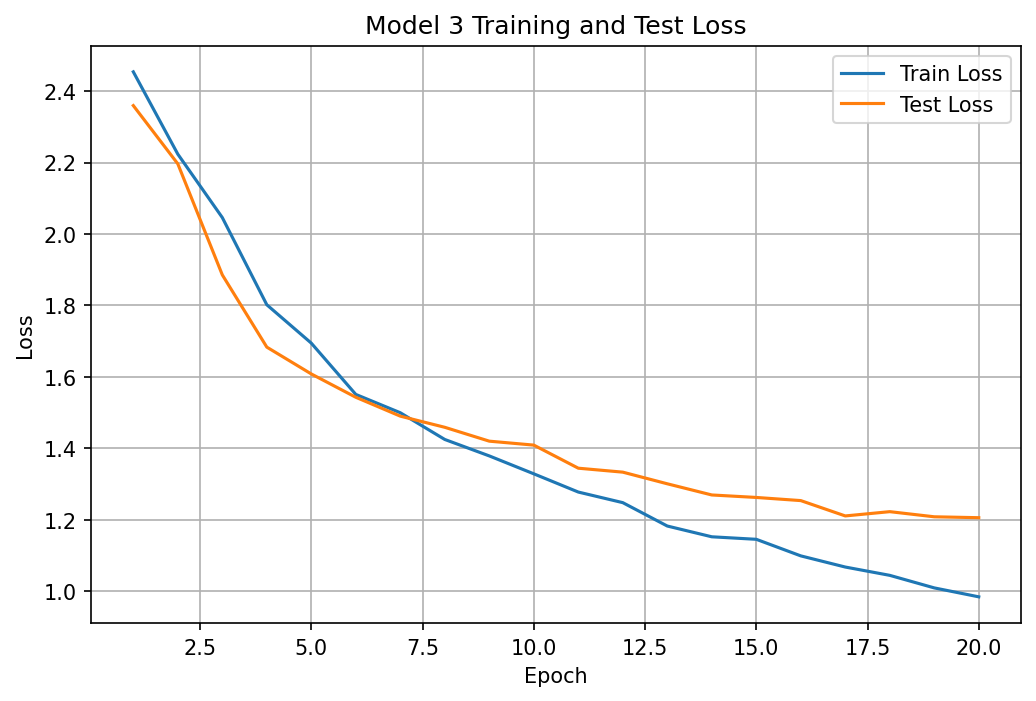

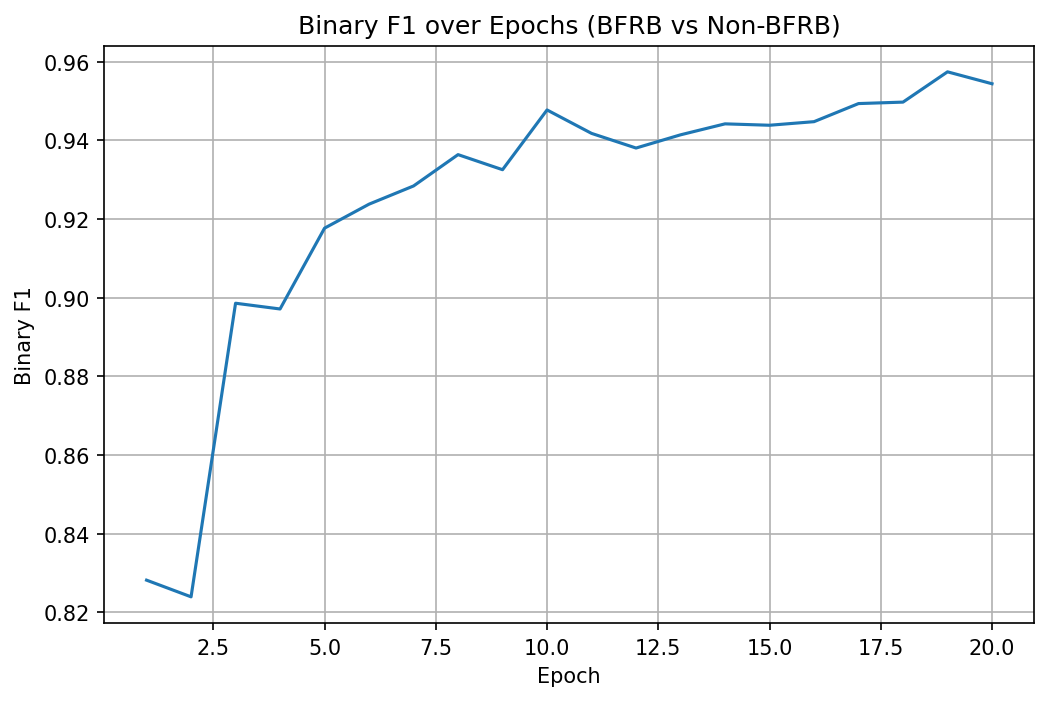

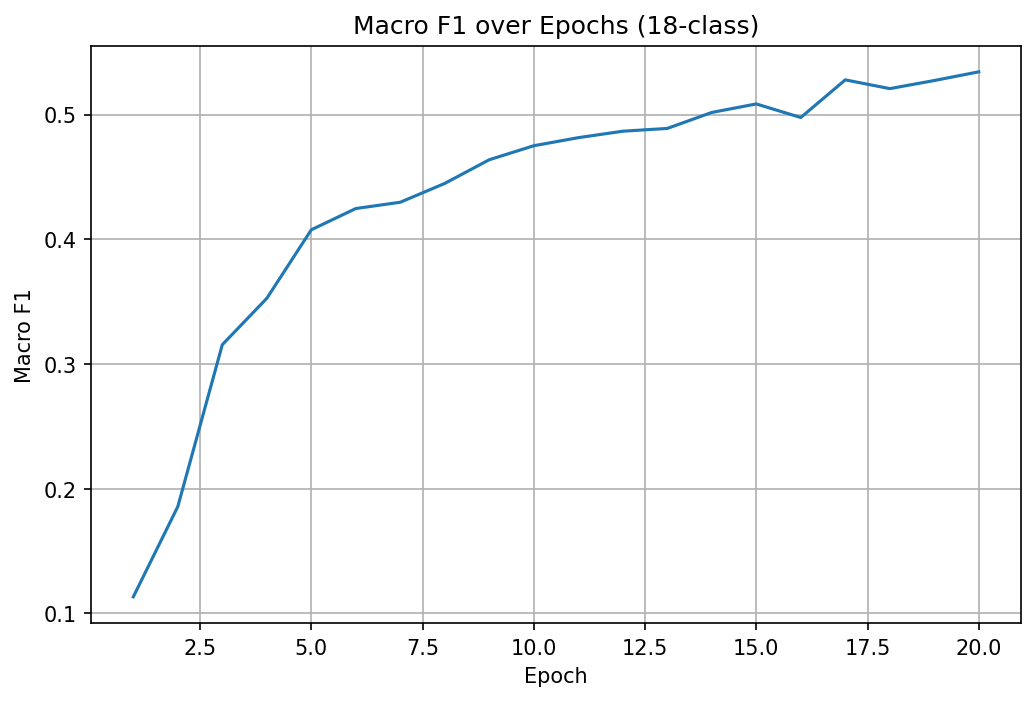

Success! All 3 line plots have been saved to: E:\A1_last_version\plots\model3_cnn


In [18]:
# =========================
# Module: Generate and Save Line Plots
# =========================
import matplotlib.pyplot as plt

# 1. Safely create your plots folder
plot_dir = PROJECT_ROOT / "plots" / "model3_cnn"
plot_dir.mkdir(parents=True, exist_ok=True) 

# Create a list of numbers from 1 to 20 for the bottom (X-axis) of our graphs
epoch_list = range(1, epochs + 1)

# 2. Plot 1: Loss Curve (Train vs Test)
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(epoch_list, train_losses, label='Train Loss')
plt.plot(epoch_list, test_losses, label='Test Loss')
plt.title('Model 3 Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True) 
plt.legend()
plt.savefig(plot_dir / "loss_curve.png")
plt.show()
plt.close()

# 3. Plot 2: Binary F1 Curve
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(epoch_list, test_binary_f1s)
plt.title('Binary F1 over Epochs (BFRB vs Non-BFRB)')
plt.xlabel('Epoch')
plt.ylabel('Binary F1')
plt.grid(True)
plt.savefig(plot_dir / "binary_f1_curve.png")
plt.show()
plt.close()

# 4. Plot 3: Macro F1 Curve
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(epoch_list, test_macro_f1s)
plt.title('Macro F1 over Epochs (18-class)')
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.grid(True)
plt.savefig(plot_dir / "macro_f1_curve.png")
plt.show()
plt.close()

print(f"Success! All 3 line plots have been saved to: {plot_dir}")

In [19]:
import json
from sklearn.metrics import accuracy_score
SUMMARY_DIR = PROJECT_ROOT / "results" / "Model3_Training"

SUMMARY_DIR.mkdir(parents=True, exist_ok=True) 

# Calculate the final accuracy
final_acc = accuracy_score(epoch_labels, epoch_preds)

# Create the summary dictionary
summary = {
    "final_metrics": {
        "acc": float(final_acc),
        "macroF1": float(test_macro_f1s[-1]),
        "binaryF1": float(test_binary_f1s[-1])
    }
}

#Save it as a JSON file
summary_path = SUMMARY_DIR / "model3_training_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved everything to:", SUMMARY_DIR)
print("Saved:", summary_path)
print("Final metrics:", summary["final_metrics"])

Saved everything to: E:\A1_last_version\results\Model3_Training
Saved: E:\A1_last_version\results\Model3_Training\model3_training_summary.json
Final metrics: {'acc': 0.5487483530961792, 'macroF1': 0.5342583566321166, 'binaryF1': 0.9544041450777202}
